# Friday Academy 2025
# Advance Prompting and agentic concepts in Generative AI"
<img src="./images/ai_powered_employee.jpg" alt="Alt text" width="1500" height="1200">

##### Date: 21 - Nov - 2025

## Agenda
* ### Introduction to Prompting and examples
* ### Prompting with Langchain
* ### Advance Prompting Technique
* ### Agentic AI

### Dependencies

In [48]:
import os
path = os.path.join(os.getcwd(),'work')
# Relative path to the .env
dotenv_path = os.path.join(path, ".env")

In [49]:
# %pip install -r "{path}"/requirements.txt

In [50]:
# Import necessary modules
from dotenv import load_dotenv

# Import OpenAI wrapper for Azure
from langchain_openai import AzureChatOpenAI

# Import message graph utilities
# from langgraph.graph import END

# Load environment variables from a .env file
load_dotenv()
os.environ["OPENAI_API_VERSION"] = os.getenv('OPENAI_API_VERSION')
os.environ["AZURE_OPENAI_ENDPOINT"] = os.getenv('AZURE_OPENAI_ENDPOINT')
os.environ["AZURE_OPENAI_API_KEY"] = os.getenv('AZURE_OPENAI_API_KEY')
deployment=os.getenv('AZURE_OPENAI_DEPLOYMENT')

## 1. Introduction to prompting and examples

<img src="images/prompt.png" alt="Alt text" width="1000" height="900">


In [51]:
# First code to start 
from openai import AzureOpenAI

# Initialize the AzureOpenAI client.
# The AzureOpenAI client allows us to interact with the Azure-hosted OpenAI services.
client = AzureOpenAI(
  azure_endpoint = os.getenv("AZURE_OPENAI_ENDPOINT"), 
  api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    api_version="2024-12-01-preview",
)


In [52]:
message_automotive = [
    {
        "role": "system",
        "content": (
            "You are an automotive assistant, you must technically provide your answer only related to automotive. "
            "Instructions: "
            "- If the query is not related to automotive, you can say 'I do not know' or 'I am not sure'."
        )
    },
    {
        "role": "user",
        # Related to automotive
        # "content": "what is ADAS?"
        "content": "Can you give me an overview of current safety features of cars?"
        
        # Not related to automotive
        # "content": "what is software development?"
    }
]


In [53]:
response = client.chat.completions.create(
    model=deployment,
    messages=message_automotive,
    temperature=0,
    max_tokens=200,
)
print(response.choices[0].message.content)

Certainly! Current safety features in cars have advanced significantly and can be categorized into several key areas:

1. **Active Safety Features**:
   - **Anti-lock Braking System (ABS)**: Prevents wheel lock-up during braking.
   - **Electronic Stability Control (ESC)**: Helps maintain vehicle control during extreme steering maneuvers.
   - **Traction Control System (TCS)**: Prevents wheel spin during acceleration.
   - **Adaptive Cruise Control (ACC)**: Automatically adjusts the vehicle's speed to maintain a safe distance from the car ahead.
   - **Lane Departure Warning (LDW) and Lane Keeping Assist (LKA)**: Alerts the driver if the vehicle drifts out of its lane and can provide steering assistance to keep it in the lane.

2. **Passive Safety Features**:
   - **Airbags**: Front, side, curtain, and knee airbags provide cushioning during a collision.
   - **Seatbelts**: Equipped with pre-tensioners


### 1.1 The Basic Ingredients of a Prompt

<img src="images/basic_prompting.png" alt="Alt text" width="1000" height="900">


### 1.2 The Potential Complexity of a Prompt

<img src="images/complex_prompt.png" alt="Alt text" width="800" height="700">


In [54]:
#example
# Prompt components
persona = "You are an expert in Large Language models. You excel at breaking down complex papers into digestible summaries.\n"
instruction = "Summarize the key findings of the paper provided.\n"
context = "Your summary should extract the most crucial points that can help researchers quickly understand the most vital information of the paper.\n"
data_format = "Create a bullet-point summary that outlines the method. Follow this up with a concise paragraph that encapsulates the main results.\n"
audience = "The summary is designed for busy researchers that quickly need to grasp the newest trends in Large Language Models.\n"
tone = "The tone should be professional and clear.\n"
data = "Text to summarize: PUT_THE_DATA_TO_SUMMARIZE_HERE"

# The full prompt - remove and add pieces to view its impact on the generated output
query = persona + instruction + context + data_format + audience + tone + data

# prompt = format_prompt(query)
print(query)

You are an expert in Large Language models. You excel at breaking down complex papers into digestible summaries.
Summarize the key findings of the paper provided.
Your summary should extract the most crucial points that can help researchers quickly understand the most vital information of the paper.
Create a bullet-point summary that outlines the method. Follow this up with a concise paragraph that encapsulates the main results.
The summary is designed for busy researchers that quickly need to grasp the newest trends in Large Language Models.
The tone should be professional and clear.
Text to summarize: PUT_THE_DATA_TO_SUMMARIZE_HERE


### 1.3 Structured Output 
##### Incase if you want the response as dictionary

In [55]:
import pprint
output_dict = response.model_dump() 
pprint.pprint(output_dict)

{'choices': [{'content_filter_results': {'hate': {'filtered': False,
                                                  'severity': 'safe'},
                                         'protected_material_code': {'detected': False,
                                                                     'filtered': False},
                                         'protected_material_text': {'detected': False,
                                                                     'filtered': False},
                                         'self_harm': {'filtered': False,
                                                       'severity': 'safe'},
                                         'sexual': {'filtered': False,
                                                    'severity': 'safe'},
                                         'violence': {'filtered': False,
                                                      'severity': 'safe'}},
              'finish_reason': 'length',
              'index':

### 1.4 Tracking tokens generated
##### Get the token counts, which translate into costs

In [56]:
# Find the the token and costing 
print(output_dict['usage'])

{'completion_tokens': 200, 'prompt_tokens': 69, 'total_tokens': 269, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}


### 1.5 Controlling Response Randomness: Temperature

**Temperature:** 
 - Control on determinism.
 -  Ranges from 0 (highly deterministic) to 2 (very random).




In [57]:
# Define the prompt
prompt = "Describe a sports car driving down a highway."

# Set low and high temperature values
low_temp = 0.0
high_temp = 0.9

# Function to generate a response with a specified temperature
def generate_response(temperature):
    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature,
        max_tokens=200
    )
    return response.choices[0].message.content

# Generate responses with different temperature values
low_temp_response = generate_response(low_temp)
high_temp_response = generate_response(high_temp)

# Print the responses
print(f'Temperature = {low_temp}, Response: {low_temp_response}')


Temperature = 0.0, Response: The sun glints off the sleek, aerodynamic body of the sports car as it glides down the highway, a vibrant shade of red that catches the eye of every passerby. Its low profile hugs the asphalt, and the roar of the engine resonates like a symphony of power and precision. The driver grips the leather-wrapped steering wheel, feeling the responsive handling as they navigate the curves of the road with ease.

As the car accelerates, the world blurs into a streak of colors—green trees, blue skies, and the occasional flash of a distant mountain. The wind rushes through the open windows, creating a thrilling rush that complements the adrenaline coursing through the driver’s veins. The dashboard is a blend of cutting-edge technology and classic design, with digital displays showing speed, navigation, and performance metrics.

With each shift of the gears, the car surges forward, the tires gripping the pavement with confidence. The sound of the exhaust is a deep growl

In [58]:
print(f'\nTemperature = {high_temp},\n Response: {high_temp_response}')


Temperature = 0.9,
 Response: The sun glints off the sleek, aerodynamic curves of the sports car as it glides down the highway, leaving a blur of color in its wake. The engine roars to life, a powerful growl that resonates deep within the chassis, sending a thrill through the driver. With precision engineering, the car hugs the road, its low profile and wide stance providing exceptional stability as it navigates gentle curves and sharp bends.

The vibrant paint job—perhaps a striking red or a deep metallic blue—catches the light, drawing the eyes of passing motorists. The 20-inch alloy wheels spin effortlessly, a testament to the car's finely-tuned performance. Inside, the cockpit is a marriage of luxury and functionality, with leather seats that cradle the driver and state-of-the-art technology at their fingertips.

As the car accelerates, the world outside becomes a blur—the scenery of trees, hills, and distant mountains rushing past in a kaleidoscope of colors. Wind rushes through 

## 2. Prompting with LangChain

##### What is LangChain?
- LangChain is a framework designed to build applications using language models.
- It helps in managing prompts, chains of calls, and agent logic.
- Provides a seamless way to integrate various LLMs (Large Language Models) and API calls.

##### Why Use Prompting with LangChain?
- **Simplifies Prompt Management**: Centralizes prompt templates, making it easier to update or switch out prompts.
- **Structured Approach**: Helps in creating complex chains of prompts that interact with different APIs or models.
- **Enhanced Flexibility**: Customizes responses from LLMs to better align with specific use cases, like generating reports, answering questions, or analyzing data.
  
##### Key Concepts
- **Prompt Templates**: Define the structure of prompts, making them reusable and adaptable to different inputs.
- **Chains**: A series of calls or prompts that can be executed in sequence or in a decision-based manner.
- **Agents**: Components that can make decisions and dynamically interact with external tools or APIs based on prompts.

 <img src="images/Langchain.png" alt="Alt text" width="1000" height="900">


### 2.1 Example using PromptTemplate

In [59]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser


In [60]:
# Set up a parser + inject instructions into the prompt template.
parser = JsonOutputParser()

In [61]:
template = "You are an automotive expert, answer the question.\n{format_instructions}\n {question}"
prompt_template = PromptTemplate(
    template=template,
    input_variables=["question"],
    partial_variables={"format_instructions": parser.get_format_instructions()},
)


In [62]:
print(prompt_template.invoke({"question": "What is ABS"}))

text='You are an automotive expert, answer the question.\nReturn a JSON object.\n What is ABS'


In [63]:
# Let's integrate with LLM
llm = AzureChatOpenAI(
    # openai_api_version="2024-07-18",
    azure_deployment=deployment,)

In [64]:
llm

AzureChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x000001FD52CC28A0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001FD52CC2F30>, root_client=<openai.lib.azure.AzureOpenAI object at 0x000001FD52A92AB0>, root_async_client=<openai.lib.azure.AsyncAzureOpenAI object at 0x000001FD52CC28D0>, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True, disabled_params={'parallel_tool_calls': None}, azure_endpoint='https://autosarbuildercopilot.openai.azure.com/', deployment_name='gpt-4o-mini', openai_api_version='2024-12-01-preview', openai_api_type='azure')

### 2.2 Chaining in Langchain

In [65]:
# Langchain expression language (LCEL)
# Connect calls to different component -prompt_template and LLM
llm_chain = prompt_template | llm 
question = "What is ABS"
llm_chain.invoke({"question": question})

AIMessage(content='```json\n{\n  "term": "ABS",\n  "full_form": "Anti-lock Braking System",\n  "definition": "ABS is a safety system in vehicles that prevents the wheels from locking up during braking, allowing the driver to maintain steering control.",\n  "how_it_works": {\n    "sensors": "ABS uses wheel speed sensors to monitor the rotational speed of each wheel.",\n    "control_unit": "If the system detects that a wheel is about to lock up, it sends a signal to the hydraulic control unit.",\n    "brake_modulation": "The hydraulic control unit can rapidly modulate brake pressure to the wheel, releasing brakes momentarily to prevent locking.",\n    "driver_effect": "This allows the driver to steer the vehicle while braking hard, improving control and reducing the risk of skidding."\n  },\n  "benefits": [\n    "Improved vehicle control during emergency braking.",\n    "Reduced stopping distance on slippery surfaces.",\n    "Increased overall safety in various driving conditions."\n  ],

In [66]:
# Langchain expression language (LCEL)
# connect calls to different component --prompt_template, LLM, output parser
llm_chain = prompt_template | llm | parser
question = "What is ABS"
print(llm_chain.invoke({"question": question}))

{'ABS': {'full_form': 'Anti-lock Braking System', 'definition': 'A safety anti-skid braking system that prevents the wheels from locking up during braking by modulating brake pressure.', 'components': {'wheel_sensors': 'Measure the rotational speed of each wheel.', 'electronic_control_unit': 'Processes data from wheel sensors and modulates brake pressure.', 'hydraulic_control_unit': 'Applies brakes to each wheel as needed based on signals from the electronic control unit.'}, 'benefits': ['Prevents loss of steering control during hard braking.', 'Reduces stopping distances on slippery surfaces.', 'Enhances vehicle stability and control.'], 'common_usage': 'Widely used in modern vehicles for improved safety on roads.'}}


## 3. Advance prompting technique

### 3.1 In-Context Learning

In more complex scenarios, models may lack the necessary understanding or context to generate an appropriate response based solely on a given prompt. In such cases, it is beneficial to provide examples to the model, enabling it to learn and adapt from these examples—a process known as *in-context learning*.


#### 3.1.1 Few short prompting

<img src="./../ai_convention_2024/session_2/few_shot.png" alt="Alt text" width="800" height="600">


In [67]:
from langchain_core.prompts import ChatPromptTemplate, FewShotChatMessagePromptTemplate

In [68]:
# source for reviews : https://www.amazon.in/Urban-Terrain-Performance-Mountain-Suspension/dp/B0CVH8LGTZ/ref=zg_bs_g_3403870031_d_sccl_1/262-5569152-5785625?th=1

examples = [
    {"input" : "The cycle is smooth and easy to ride and especially the wheel is strong and can ride in tough terrain.. Installation person was knowledgeable and on time/discipline.", "output": "positive"},
    {"input" : "Don't buy above 150 height of men because it's very small cycle for child 10 year and I faced many issue. bearing jammed and small wheel but overall good for children. bult quality is so good.", "output":"negative" },
    {"input" : "The Cycle is good and its up and running, but the package / box was torn, open from bottom. looked like it was lying in the warehouse for a long time. had dust and dirt all over it. screws of fenders and other parts were missing. We got them fixed from the cycle shop. but overall the product is good and did not have damage to itself", "output":"neutral"},
    {"input" : "it is a very nice cycle with quality parts and reliable service. highly recommended if u want a good cycle in medium range price", "output": "positive"}
]
example_prompt = ChatPromptTemplate.from_messages([("human", "{input}"), ("ai", "{output}")])
few_shot_prompt = FewShotChatMessagePromptTemplate(example_prompt=example_prompt, examples= examples)
final_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "your a bycycle reviewer who will give sentiment of the review for user input "),
        # uncomment for illustration
        # few_shot_prompt,
        ("human", "{input}"),
    ]
)

In [69]:
chain = final_prompt | llm
res = chain.invoke("""it is a very nice cycle with quality parts and reliable service.highly recommended if u want a good cycle in medium range price.""")
print(res.content)

The sentiment of your review is very positive! You highlight the quality of the parts, the reliability of the service, and recommend it highly for those seeking a good bicycle in the medium price range. Overall, it conveys satisfaction and endorsement.


#### 3.1.2 Chain of thought prompting 


<img src="images/chain_of_thought.png" alt="Alt text" width="800" height="600">


In [70]:
# Define the question
question = """
I went to the market and bought 10 apples. I gave 2 apples to the neighbor and 2 to the repairman. 
I then went and bought 5 more apples and ate 1. 
How many apples did I remain with?

Let's think step by step.
"""

# Run the model to get the response
response = llm.invoke(question)

# Print the model's response
print(response.content)

Let's break it down step by step:

1. You initially bought 10 apples.
2. You gave 2 apples to the neighbor: 
   - 10 - 2 = 8 apples remaining.
3. You gave 2 apples to the repairman: 
   - 8 - 2 = 6 apples remaining.
4. You then bought 5 more apples: 
   - 6 + 5 = 11 apples remaining.
5. You ate 1 apple: 
   - 11 - 1 = 10 apples remaining.

So, after all these actions, you have 10 apples remaining.


#### 3.1.3 Self-Consistency


<img src="images/self.consistancy.png" alt="Alt text" width="1000" height="900">


In [71]:

# Define the problem statement
problem = "If there are 10 cars in the parking lot and 3 more cars arrive. Half the original number of cars leave. Then, half of the current number of cars arrive. How many cars are there in the parking?"

# Define a prompt template that simulates three independent experts reasoning
template = """
Imagine three completely independent experts who reason differently are answering this question. 
Each expert will solve the problem step by step, and the final answer is obtained by majority vote.

Problem: {problem}

Expert 1: Let's think through this step by step.

Expert 2: Let's consider each part of the problem carefully.

Expert 3: I will analyze the situation and calculate the answer step by step.

Final answer:
"""

# Create a PromptTemplate with the input variable and template text
prompt = PromptTemplate(
    input_variables=["problem"],
    template=template
)

# Create the LLMChain with the language model and the prompt template
Self_Consistenc_chain = prompt | llm

# Run the LLMChain with the problem as input
response = Self_Consistenc_chain.invoke( problem)

# Print the result
print(response.content)


Let's go through the problem step by step as each expert might do.

**Expert 1:**
1. Start with the original number of cars in the parking lot: 10 cars.
2. 3 more cars arrive: 10 + 3 = 13 cars.
3. Half the original number of cars leave: Half of 10 is 5, so 13 - 5 = 8 cars remain.
4. Half of the current number of cars now arrive: Half of 8 is 4, so 8 + 4 = 12 cars in total.

**Expert 1's final answer:** 12 cars.

---

**Expert 2:**
1. Initial count of cars: 10 cars.
2. After 3 more cars arrive: 10 + 3 = 13 cars.
3. Calculate half the original number (10): 10 / 2 = 5 cars leave.
4. Update the count after cars leave: 13 - 5 = 8 cars.
5. Now, calculate half of this current number (8): 8 / 2 = 4 cars arrive.
6. Final count of cars after these cars arrive: 8 + 4 = 12 cars.

**Expert 2's final answer:** 12 cars.

---

**Expert 3:**
1. We begin with 10 cars.
2. 3 cars arrive, so: 10 + 3 = 13 cars in total.
3. We need to determine how many cars leave. Half of the initial number (10) leaves: 10 

### 3.2 Tool Calling with LangChain
- Large Language Models (LLMs) can interact with external data sources via **tool calling functionality**.
- Tool calling is a powerful technique that enables:
    - **Developers to build sophisticated applications** leveraging LLMs.
    - **Access, interaction, and manipulation of external resources** like:
        - Databases
        - Files
        - APIs


In [72]:
from langchain_core.tools import tool

@tool
def multiply(a: int, b: int) -> int:
    """Multiply a and b."""
    return a * b

tools = [multiply]

llm_with_tools = llm.bind_tools(tools)

In [73]:
result_1 = llm_with_tools.invoke("Hello world!")
print(result_1.content)

Hello! How can I assist you today?


In [74]:
result_1.tool_calls

[]

In [75]:
result_2 = llm_with_tools.invoke("What is 2 times 3?")
result_2

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_FNcq0xZ3Dz85w4eaQMwJsGD7', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 53, 'total_tokens': 71, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_efad92c60b', 'id': 'chatcmpl-Cb0NurEuSQl4j0zhGhzv7bSoOOYqq', 'service_tier': None, 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'filtered': False, 'detected': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_

In [76]:
# Run the tool.
tool_call = result_2.tool_calls[0]

eval(tool_call['name']).func(**tool_call['args'])

6

In [77]:
result_2.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'call_FNcq0xZ3Dz85w4eaQMwJsGD7',
  'type': 'tool_call'}]

## 4. Agentic AI 

### 4.1 What are AI agents?
_______
* A system or program that perform tasks autonomously on behalf of the user or another system.
* Solve complex problems over multiple-steps using sophisticated reasoning and iterative planning.
* It encompasses wide range of functionality like, decision-making, problem solving, interacting with internal nad extrnal enviroments and taking actions.

<img src="./images/Autonomous_agent_workflow.png" alt="Alt text" width="700" height="500">

#### 4.1.1 Frameworks for Agentic AI
________

   <img src="./images/Agentic_AI.png" alt="Alt text" width="800" height="600">

#### 4.1.2 When (and when not) to use agents
______
   <img src="./images/dos_and_dont.png" alt="Alt text" width="600" height="400">


### 4.2 LangGraph


 - LangGraph library is used for building stateful, multi-actor applications with LLMs, used to create agent and multi-agent workflows.

 - Built on top of LangChain, primarily introduced for its easy way of creating cyclical graphs.

<img src="./images/TheSpectrumofLLMAgency.png" alt="Alt text" width="800" height="400">


- Custom chains function as directed acyclic graphs (DAGs) without cycles.
  
- Cycles in complex LLM applications allow LLMs to reason and determine next steps. Running an LLM in a loop enhances flexibility and handles more ambiguous use-cases.

  
- Agents operate in a loop, with the LLM determining actions and responses iteratively. LangGraph enables creation of state machines, allowing for control


### 4.3 Core Data strutucture of LangGraph 

In [78]:
"""# Dict vs TypedDict vs Pydantic
"""
# Import necessary modules
from pydantic import BaseModel, EmailStr


In [79]:
employee_1 ={"name": "Naveen","age": 25}
emplyee_2 = {"name": "Vivek","Age": 26, 'job':'Technical Architect'}

In [80]:
# Using TypedDict

from typing import TypedDict

class Employee(TypedDict):
    name: str
    age: int

employee_1: Employee = {
    "name": "Naveen",
    "age": 25,
}

print(employee_1["name"])  # Works fine

Naveen


In [81]:
# Using Pydantic

class Employee(BaseModel):
    name: str
    age: int

# Creating a Employee
emp_1 = Employee(name="Naveen", age=25)
# # Creating a invalid Employee
# emp_1 = UserModel(name="Vivek", age='twenty six')

### 4.4 Core Concepts

##### 1. State:
   State is the foundation of LangGraph applications and can be a simple dictionary or a Pydantic model. 
   It contains all the information needed during application runtime.

##### 2. Node:
   Nodes are typically Python functions used to process state and return updated state.
   Each node represents a discrete step in your workflow. 
   Rather than cramming every operation into a single class, you isolate each task, such as data transformation, validation, or decision-making into its own node. 
   This modular design reduces complexity by giving each node a single responsibility.

##### 3. Edge:
   Edges define the connections and routing logic between nodes. 
   They act as directed connections, ensuring that outputs from one node become the inputs to the next node in a predictable sequence. 
   This explicit control over how data advances makes the entire workflow easy to visualize, debug, and update without risking side effects elsewhere.

In [82]:
from langgraph.graph import END, START, StateGraph
from typing import TypedDict

# Define the state structure
class InputState(TypedDict):
    string_value: str
    numeric_value: int

def node_a(input: InputState):
    print(f"State A received: {input}")

    input['string_value'] *=3
    return input

def node_b(input: InputState):
    print(f"State B received: {input}")
    input["numeric_value"] *= 2  # Add the same value twice
    print(f"State B modified: {input}")
    return input

# Create the state graph
graph = StateGraph(InputState)

graph.add_node("State A", node_a)
graph.add_node("State B", node_b)

graph.add_edge(START, "State A")
graph.add_edge("State A", "State B")
graph.add_edge("State B", END)


# Compile the graph
runnable = graph.compile()

In [83]:
# Run with an initial state
# initial_state = {"string_value": "example"}
initial_state = {"string_value": "example", "numeric_value": 10}
result = runnable.invoke(initial_state)
print("Final result:", result)

State A received: {'string_value': 'example', 'numeric_value': 10}
State B received: {'string_value': 'exampleexampleexample', 'numeric_value': 10}
State B modified: {'string_value': 'exampleexampleexample', 'numeric_value': 20}
Final result: {'string_value': 'exampleexampleexample', 'numeric_value': 20}


####  Visualize the graph

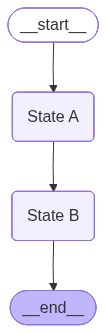

In [84]:
runnable = graph.compile()
from IPython.display import Image, display
try:
    display(Image(runnable.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

### 4.5 Cycles and Conditional Edges

In [85]:
def node_a(input: InputState):
    print(f"State A received: {input}")

    input['string_value'] *=3
    return input

def node_b(input: InputState):
    print(f"State B received: {input}")
    input["numeric_value"] *= 2  # Add the same value twice
    print(f"State B modified: {input}")
    return input
def node_c(input: InputState):
    print(f"State c received: {input}")
    input["numeric_value"]= min(input["numeric_value"],100)
    return input
    
def router(input: InputState):
    if input["numeric_value"] > 100:
        return "c"
    else:
        return "__end__"
        
# Create the state graph
graph = StateGraph(InputState)

graph.add_node("State A", node_a)
graph.add_node("State B", node_b)
graph.add_node("State C", node_c)



graph.add_edge(START, "State A")
graph.add_edge("State A", "State B")
graph.add_edge("State C", END)
#conditional edge

graph.add_conditional_edges(
    "State B", router, {"c": "State C", "__end__": END}
)


# Compile the graph
runnable = graph.compile()

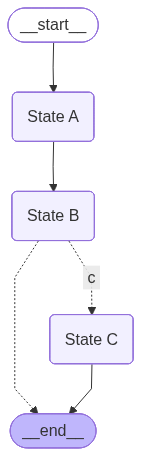

In [86]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        runnable.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [87]:
runnable.invoke({"string_value": "abc", "numeric_value": 5})

State A received: {'string_value': 'abc', 'numeric_value': 5}
State B received: {'string_value': 'abcabcabc', 'numeric_value': 5}
State B modified: {'string_value': 'abcabcabc', 'numeric_value': 10}


{'string_value': 'abcabcabc', 'numeric_value': 10}

In [88]:
runnable.invoke({"string_value": "a", "numeric_value": 60})

State A received: {'string_value': 'a', 'numeric_value': 60}
State B received: {'string_value': 'aaa', 'numeric_value': 60}
State B modified: {'string_value': 'aaa', 'numeric_value': 120}
State c received: {'string_value': 'aaa', 'numeric_value': 120}


{'string_value': 'aaa', 'numeric_value': 100}

### 4.6 Pratical example-Chatbot

In [89]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, END

from langgraph.graph.message import add_messages, AnyMessage

class AgentState(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list[AnyMessage], add_messages]

In [90]:
graph_builder = StateGraph(AgentState)

#### 4.6.1 Initilize the LLM and chatnode

In [91]:
llm = AzureChatOpenAI(
    openai_api_version="2024-02-01",
    azure_deployment=deployment,)
def chat(state: AgentState):
    return {"messages": [llm.invoke(state["messages"])]}

graph_builder.add_node("chat", chat)

In [92]:
graph_builder.set_entry_point("chat")
graph_builder.set_finish_point("chat")
graph_ = graph_builder.compile(checkpointer=MemorySaver())


#### 4.6.2 Visualize the graph

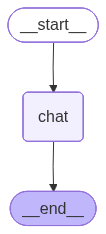

In [93]:
graph = graph_builder.compile()
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [94]:
# Run the chatbot
# To end the chat, type "quit", "exit", or "q" or click the "Interrupt the kernel" button (Stop symbol) in the command panel at the top of this notebook.

while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
    config = {"configurable": {"thread_id": "1"}}
    for event in graph_.stream({"messages": [("user", user_input)]}, config=config):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

Goodbye!


## References

- [NVIDIA Generative AI Glossary](https://www.nvidia.com/en-us/glossary/generative-ai/)  
- [Microsoft Azure Prompt Flow Overview](https://learn.microsoft.com/en-us/azure/machine-learning/prompt-flow/overview-what-is-prompt-flow?view=azureml-api-2)  
- Alto, V. (2024). *Building LLM Powered Applications*. O'Reilly Media. [O'Reilly Link](https://learning.oreilly.com/library/view/building-llm-powered/9781835462317/Text/Chapter_04.xhtml#_idParaDest-56)  
- Alammar, J., & Grootendorst, M. (2023). *Hands-On Large Language Models*. O'Reilly Media. [O'Reilly Link](https://learning.oreilly.com/library/view/hands-on-large-language/9781098150952/)  
- Phoenix, J., & Taylor, M. (2023). *Prompt Engineering for Generative AI*. O'Reilly Media. [O'Reilly Link](https://learning.oreilly.com/library/view/prompt-engineering-for/9781098153427/)  
- [LangChain Python Documentation](https://python.langchain.com/v0.2/docs/introduction/)  
- [Prompting Guide](https://www.promptingguide.ai/techniques)  
- Brown, T. B., Mann, B., Ryder, N., Subbiah, M., Kaplan, J., Dhariwal, P., Neelakantan, A., Shyam, P., Sastry, G., Askell, A., Agarwal, S., Herbert-Voss, A., Krueger, G., Henighan, T., Child, R., Ramesh, A., Ziegler, D. M., Wu, J., Winter, C., Hesse, C., Chen, M., Sigler, E., Litwin, M., Gray, S., Chess, B., Clark, J., Berner, C., McCandlish, S., Radford, A., Sutskever, I., & Amodei, D. (2020). *Language Models are Few-Shot Learners*. arXiv preprint arXiv:2005.14165. [arXiv Link](https://arxiv.org/abs/2005.14165)  
- Wei, J., Wang, X., Schuurmans, D., Bosma, M., Ichter, B., Xia, F., Chi, E., Le, Q., & Zhou, D. (2023). *Chain-of-Thought Prompting Elicits Reasoning in Large Language Models*. arXiv preprint arXiv:2201.11903. [arXiv Link](https://arxiv.org/abs/2201.11903)  
- [Master Prompting Concepts: Chain of Thought Prompting (promptengineering.org)](https://promptengineering.org)  
- Gonen, H., et al. (2022). *Demystifying Prompts in Language Models via Perplexity Estimation*.  
- [GPT-4 Open AI ChatGPT News (Global News)](https://globalnews.ca/news/9553331/gpt-4-open-ai-chatgpt/)  
- [LangChain Multi-Agent Supervisor Tutorial](https://github.com/langchain-ai/langgraph/blob/main/docs/docs/tutorials/multi_agent/agent_supervisor.ipynb)  
- [Best Multi-Agent AI Frameworks](https://www.gettingstarted.ai/best-multi-agent-ai-framework/)  
- [Building Effective Agents - Anthropic](https://www.anthropic.com/research/building-effective-agents)  
- [Hugging Face Ethics and AI](https://huggingface.co/bloghics-soc-7)